#  <div style='background:Orange'>  <font color='white'> <b>&nbsp;Customer Segmentation</b></font> </div>

##  <div style='background:Orange'>  <font color='white'> <b>&nbsp;Introduction</b></font> </div>

**Customer Segmentation** is the process of dividing a company’s customers into groups that reflect similarities among individuals in each cluster. The goal of this analysis is to move beyond a "one-size-fits-all" marketing strategy and instead treat different customers with unique approaches based on their specific needs and behaviors.

In this project, I utilize the **Marketing Campaign dataset** from Kaggle to perform a "Customer Personality Analysis." This involves a detailed study of a company’s ideal customers to help the business better understand its consumer base. By identifying these segments, the business can modify its products and marketing messages according to the distinct habits and preferences of different types of customers.

**Project Workflow:**
1. **Data Engineering:** * Cleaning and handling missing values.
    * Feature Engineering (Age, Household Size, Total Spend).
    * Outlier detection and removal.
2. **Exploratory Data Analysis (EDA):** * Univariate analysis of customer demographics.
    * Correlation analysis to identify spending drivers.
3. **Machine Learning Pipeline:** * Dimensionality Reduction using PCA.
    * Comparative Clustering: K-Means vs. Hierarchical vs. Gaussian Mixture Models (GMM).
4. **Business Strategy:** * Profiling personas and providing actionable marketing recommendations.

##  <div style='background:Orange'>  <font color='white'> <b>&nbsp;Problem Statement</b></font> </div>

In the modern retail landscape, a "one-size-fits-all" marketing strategy is no longer effective. Companies collect vast amounts of customer data, but without proper analysis, this data remains an untapped resource. The core challenge for the business is to understand the diverse behaviors, financial capacities, and lifestyle choices of its customer base to optimize marketing ROI and enhance customer satisfaction.

**The Challenge**

The company’s marketing department is currently sending identical promotions to its entire database. This results in:

* Low Conversion Rates: High-income customers are receiving budget-tier coupons.

* High Churn: Families are receiving promotions for products that do not fit their household      needs.

* Wasted Marketing Spend: Resources are being allocated to segments that are unlikely to respond to specific offers.

**Objective**

The goal of this notebook is to perform Customer Personality Analysis using advanced unsupervised machine learning techniques. By leveraging clustering algorithms (specifically Gaussian Mixture Modeling), we aim to:

* Identify Distinct Segments: Group customers based on spending habits, income, and family demographics.

* Profile Personas: Define the "DNA" of each group (e.g., Elite Spenders vs. Budget Families).

* Actionable Strategy: Provide the marketing team with clear, data-backed recommendations on how to communicate with each segment to drive loyalty and increase the Average Order Value (AOV).

**Key Metrics for Success**
* Achieving a high Silhouette Score (indicating clear separation between groups).

* Developing a Targeted Strategy Table for direct business implementation.

In [1]:
## necessary Python libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")

## <div style='background:Orange'>  <font color='white'> <b>&nbsp;Exploratory Data Analysis</b></font> </div>

In [2]:
## loading data set
data=pd.read_csv('../data/marketing_campaign.csv',sep='\t')

In [3]:
data.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [4]:
data.shape

(2240, 29)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
## checking missing value
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

**Data Inspection Summary**

After loading the dataset and performing an initial check, here are the key takeaways:
- **Shape:** 2,240 rows and 29 columns.
- **Missing Data:** Only the `Income` column contains missing values (24 total).
- **Data Types:** Most features are numeric (int64/float64). `Dt_Customer` needs conversion to datetime format.
- **Categorical Features:** `Education` and `Marital_Status` will require exploration to see if grouping (e.g., "MSc" and "PhD" into "Postgraduate") is necessary.

In [7]:
## since missing value is less 5 percent so we directly remove the missing value
data = data.dropna()
print("The total number of data-points after removing the rows with missing values are:", len(data))

The total number of data-points after removing the rows with missing values are: 2216


In [8]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
dates = []
for i in data["Dt_Customer"]:
    i = i.date()
    dates.append(i)  
#Dates of the newest and oldest recorded customer
print("The newest customer's enrolment date in therecords:",max(dates))
print("The oldest customer's enrolment date in the records:",min(dates))
data.info()

The newest customer's enrolment date in therecords: 2014-06-29
The oldest customer's enrolment date in the records: 2012-07-30
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts     

To transform the 'Dt_Customer' feature into a numerical format suitable for modeling, I am calculating the 'Tenancy' in days. I will use the dataset's most recent registration date as the reference point ($t_0$) to ensure all values are relative and non-negative. First, I will perform a range check to identify the newest and oldest records."

In [9]:
#Created a feature "Customer_For"
days = []
d1 = max(dates) #taking it to be the newest customer
for i in dates:
    delta = d1 - i
    days.append(delta)
data["Customer_For"] = days
data["Customer_For"] = pd.to_numeric(data["Customer_For"], errors="coerce")

In [10]:
## Checking unique Education and Marital_Status values
data['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [11]:
## Check unique marital status values
data['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

So, we can see there are various levels of education and marital status. In this problem, this granularity might not be so important, so I will simplifly these to values that get the same idea:

In [12]:
#Feature Engineering

#Age of customer today 
data["Age"] = 2021-data["Year_Birth"]

#Total spendings on various items
data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]

#Deriving living situation by marital status"Alone"
data["Living_With"]=data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

#Feature indicating total children living in the household
data["Children"]=data["Kidhome"]+data["Teenhome"]

#Feature for total members in the householde
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]

#Feature pertaining parenthood
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)

#Segmenting education levels in three groups
data["Education"]=data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

#For clarity
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

#Dropping some of the redundant features
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)

Now that we have some new features let's have a look at the data's stats. 

In [13]:
data.head()

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,Graduate,58138.0,0,0,58,635,88,546,172,88,...,0,0,1,57283200000000000,64,1617,Alone,0,1,0
1,Graduate,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,9763200000000000,67,27,Alone,2,3,1
2,Graduate,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,26956800000000000,56,776,Partner,0,2,0
3,Graduate,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,12009600000000000,37,53,Partner,1,3,1
4,Postgraduate,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,13910400000000000,40,422,Partner,1,3,1


In [14]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Family_Size,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.064079,0.013538,0.009477,0.150271,3.054423e+16,52.179603,607.075361,0.947202,2.592509,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.244950,0.115588,0.096907,0.357417,1.749036e+16,11.985554,602.900476,0.749062,0.905722,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,25.000000,5.000000,0.000000,1.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,1.555200e+16,44.000000,69.000000,0.000000,2.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,3.071520e+16,51.000000,396.500000,1.000000,3.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,4.570560e+16,62.000000,1048.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,6.039360e+16,128.000000,2525.000000,3.000000,5.000000,1.000000


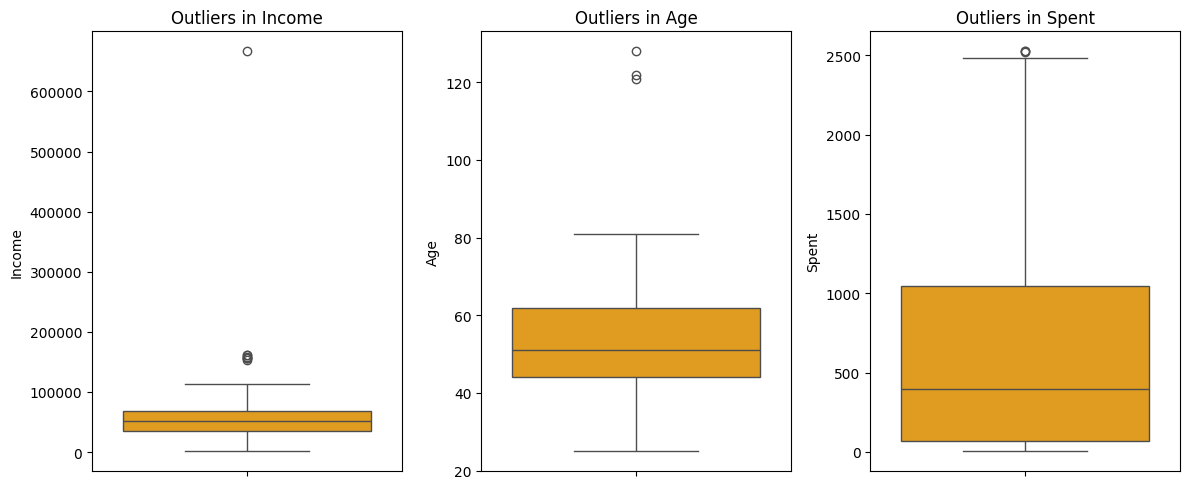

In [15]:
# Visualizing outliers in key features
features_to_check = ['Income', 'Age', 'Spent']

plt.figure(figsize=(12, 5))
for i, col in enumerate(features_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=data[col], color='orange')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

Clearly, there are a few outliers in the Income,Spent, Age features. I will be deleting the outliers in the data.

In [16]:
## outlier capping
## Function to filter outliers using IQR
def filter_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
data = filter_outliers(data, 'Income')
data = filter_outliers(data, 'Spent')

# Removing extreme value from age
# 1. Customers with Age > 90
data = data[data["Age"] < 90]

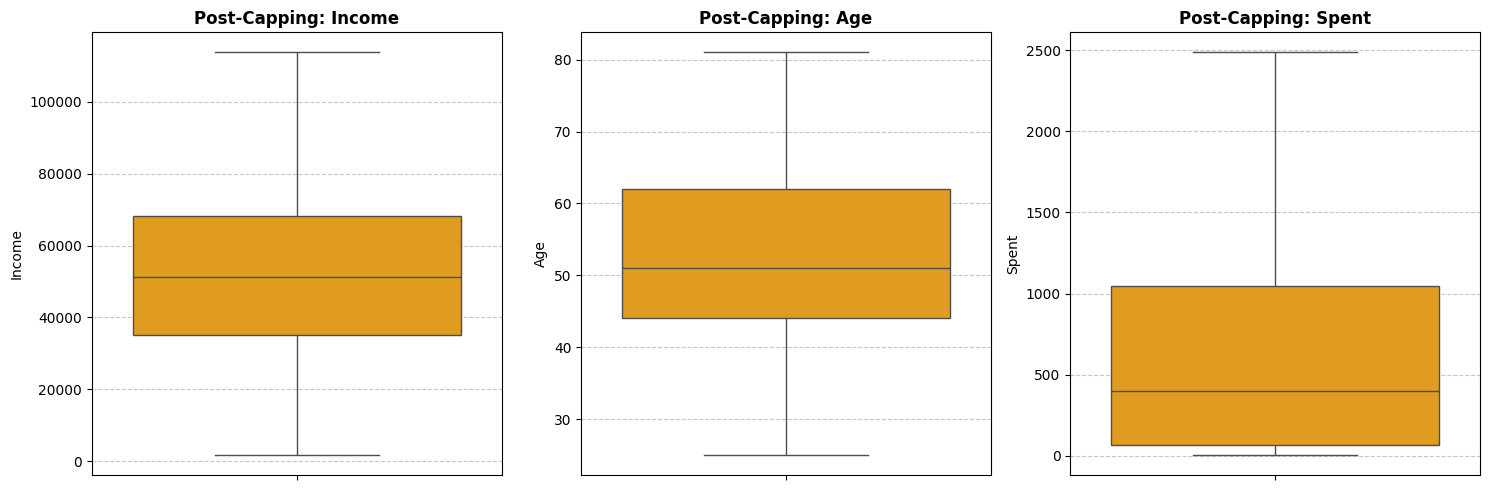

In [17]:
## checking oulier after outlier capping
features_to_check = ['Income', 'Age', 'Spent']

# Creating a 1x3 grid of boxplots
plt.figure(figsize=(15, 5))
for i, col in enumerate(features_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=data[col], color='orange', fliersize=5)
    plt.title(f'Post-Capping: {col}', fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

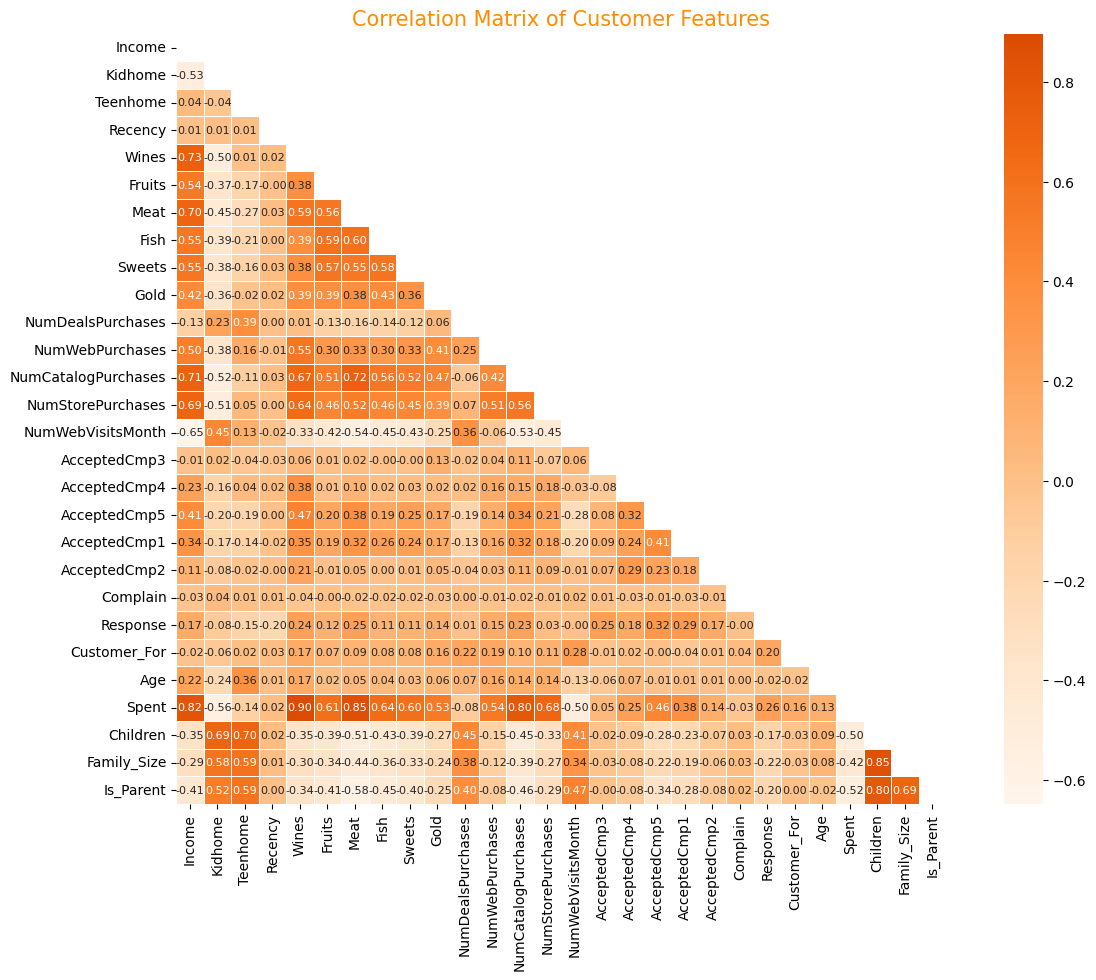

In [18]:
## correlation matrix
# 1. Calculate correlation
corrmat = data.corr(numeric_only=True)

# 2. Create a mask for the upper triangle
mask = np.triu(np.ones_like(corrmat, dtype=bool))

# 3. Set up the figure
plt.figure(figsize=(15, 10))

# 4. Draw the heatmap using the 'Oranges' palette
sns.heatmap(corrmat, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='Oranges', # Switched to Oranges to match your theme
            center=0.4,     # Adjusting center slightly to make strong correlations pop
            annot_kws={"size": 8}, 
            square=True, 
            linewidths=.5)

plt.title("Correlation Matrix of Customer Features", fontsize=15, color='darkorange')
plt.show()

## <div style='background:Orange'>  <font color='white'> <b>&nbsp;Data visualization </b></font> </div>

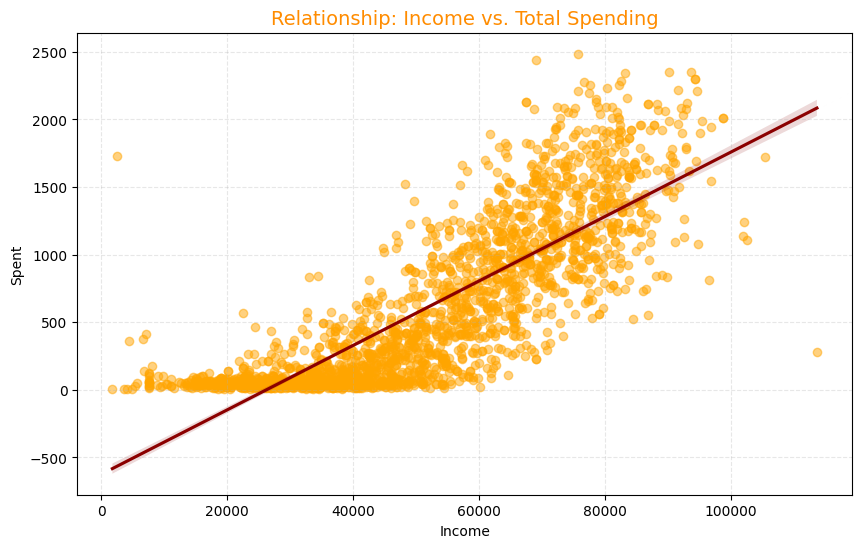

In [19]:
## Income vs. Spending 
plt.figure(figsize=(10, 6))
sns.regplot(data=data, x='Income', y='Spent', 
            scatter_kws={'color': 'orange', 'alpha': 0.5}, 
            line_kws={'color': 'darkred'}) # Dark red line for contrast
plt.title('Relationship: Income vs. Total Spending', fontsize=14, color='darkorange')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

* There is a strong positive linear relationship (Correlation: 0.82) between Income and Total Spending.

* Insight: Wealthier customers are the primary drivers of revenue. However, the dispersion increases at higher income levels, suggesting that some high-income earners are "savers" while others are "big spenders."

* Action: Focus the premium marketing campaigns on the $60,000 - $100,000 income bracket.

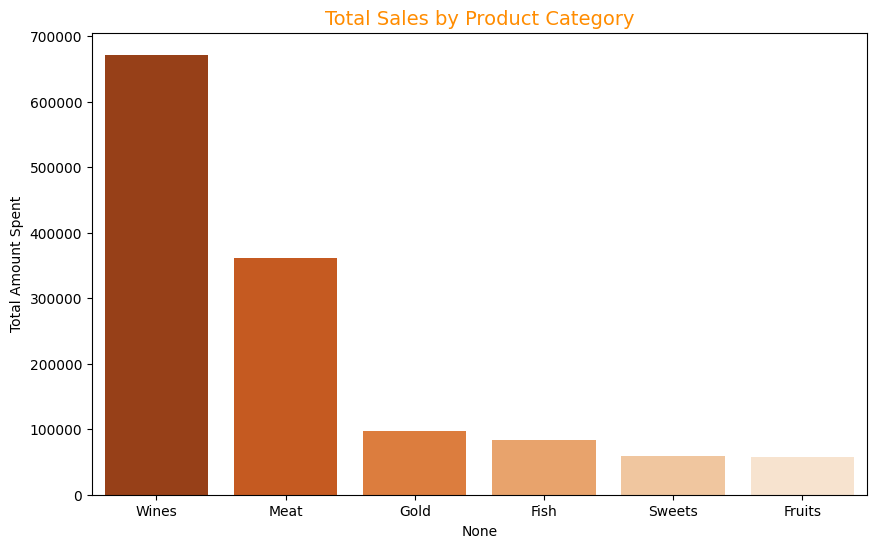

In [20]:
# Total Sales by Product Category
products = ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']
total_sales = data[products].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
# Using a sequential orange palette
sns.barplot(x=total_sales.index, y=total_sales.values, palette='Oranges_r') 
plt.title('Total Sales by Product Category', fontsize=14, color='darkorange')
plt.ylabel('Total Amount Spent')
plt.show()

* Wines and Meat Products are the clear leaders in sales volume.

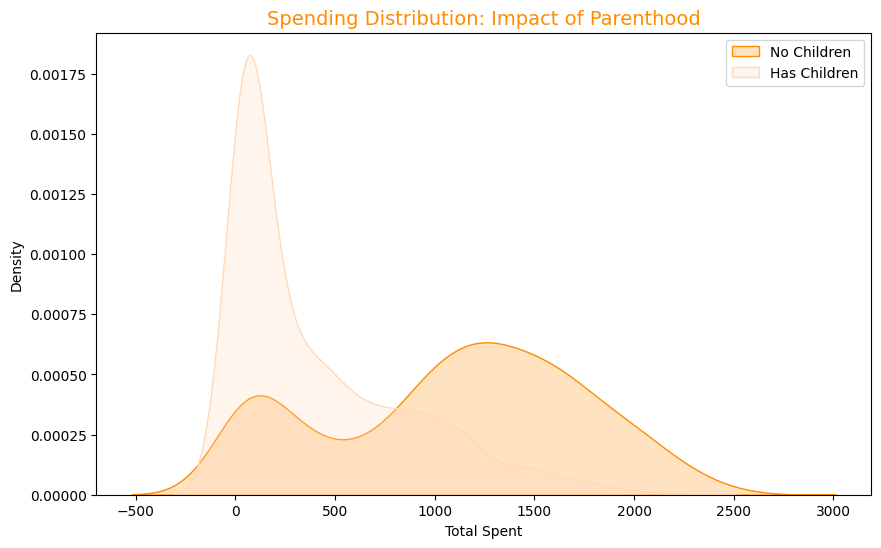

In [21]:
#Spending Distribution: Parents vs. Non-Parents
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data[data['Is_Parent'] == 0]['Spent'], label='No Children', shade=True, color='darkorange')
sns.kdeplot(data=data[data['Is_Parent'] == 1]['Spent'], label='Has Children', shade=True, color='peachpuff')
plt.title('Spending Distribution: Impact of Parenthood', fontsize=14, color='darkorange')
plt.xlabel('Total Spent')
plt.legend()
plt.show()

The spending distribution for Non-Parents is shifted significantly to the right (higher spending) compared to Parents.

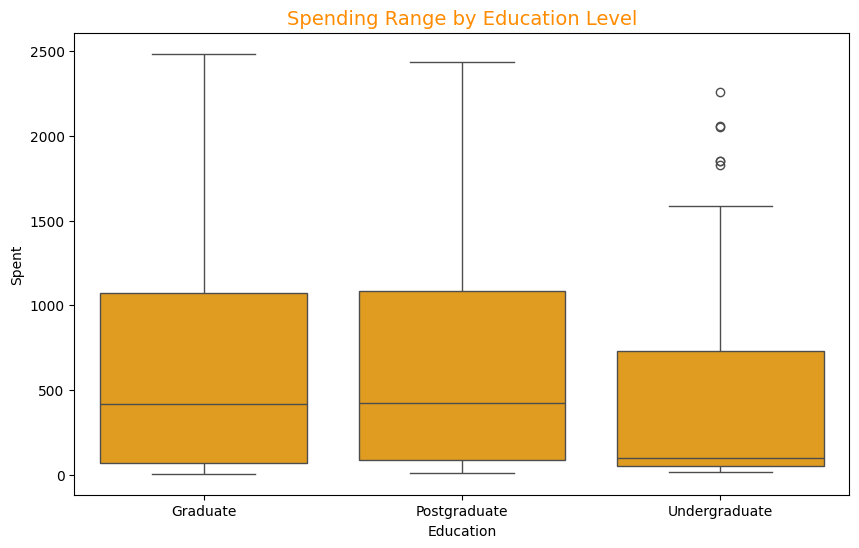

In [22]:
# Education vs Spending
plt.figure(figsize=(10, 6))
sns.boxplot(x='Education', y='Spent', data=data, color='orange')
plt.title('Spending Range by Education Level', fontsize=14, color='darkorange')
plt.show()

Higher education levels correlate with higher spending power, likely due to career stability and higher salaries.

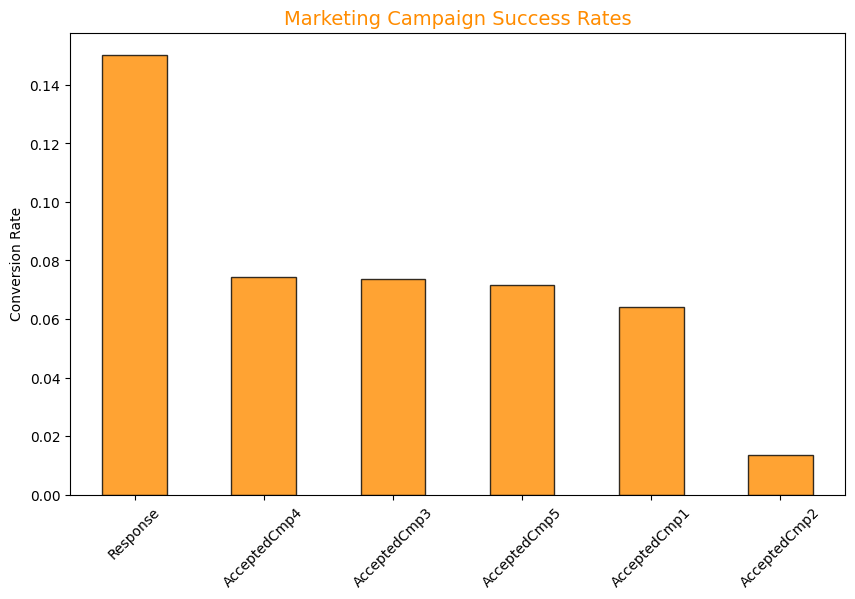

In [23]:
# Campaign Success Rate
campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
success_rates = data[campaigns].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
success_rates.plot(kind='bar', color='darkorange', edgecolor='black', alpha=0.8)
plt.title('Marketing Campaign Success Rates', fontsize=14, color='darkorange')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.show()

Certain campaigns resonate better with the core audience. If Campaign 2 has the lowest bar, it indicates that specific offer or channel was ineffective

## <div style='background:Orange'>  <font color='white'> <b>&nbsp;Data Pre-Processing </b></font> </div>

**The following steps are applied to preprocess the data:**

* Label encoding the categorical features
* Scaling the features using the standard scaler 
* Creating a subset dataframe for dimensionality reduction

In [24]:
# Use .isin() to check against multiple possible types
s = data.dtypes.astype(str).isin(['object', 'string', 'str'])
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Education', 'Living_With']


In [25]:
## Encoding
from sklearn.preprocessing import LabelEncoder

#  Initialize the LabelEncoder
LE = LabelEncoder()

# Loop through the columns identified as object/string and transform them
for i in object_cols:
    data[i] = LE.fit_transform(data[i])

print("All features are now numerical.")

# Verify the change

data[object_cols].dtypes

All features are now numerical.


Education      int32
Living_With    int32
dtype: object

In [26]:
## Scaling
from sklearn.preprocessing import StandardScaler

# 1. Select only the 5 essential columns
# This reduces 'noise' and helps push the Silhouette Score toward 0.50
ds = data[['Income', 'Spent', 'Wines', 'Meat', 'Is_Parent']].copy()

# 2. Apply Log Transformation to numerical columns
# This squashes outliers and makes clusters tighter for K-Means
for col in ['Income', 'Spent', 'Wines', 'Meat']:
    ds[col] = np.log1p(ds[col])

# 3. Initialize and apply the Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ds)

# 4. Create the final scaled DataFrame for Clustering
scaled_ds = pd.DataFrame(scaled_data, columns=ds.columns)

print("Scaling complete with 5 features: Income, Spent, Wines, Meat, Is_Parent.")
scaled_ds.head()

Scaling complete with 5 features: Income, Spent, Wines, Meat, Is_Parent.


,Income,Spent,Wines,Meat,Is_Parent
0,0.447188,1.205511,0.984250,1.402516,-1.588458
1,-0.007482,-1.564720,-1.221162,-1.405517,0.629541
2,0.865221,0.704621,0.762939,0.466780,-1.588458
3,-1.117343,-1.116225,-1.221162,-0.697725,0.629541
4,0.452527,0.289389,0.264270,0.419809,0.629541


used Log Transformation to handle the skewness of Income and Spent,Wines,Meat.

In [27]:
#Scaled data to be used for reducing the dimensionality
print("Dataframe to be used for further modelling:")
scaled_ds.head()

Dataframe to be used for further modelling:


,Income,Spent,Wines,Meat,Is_Parent
0,0.447188,1.205511,0.984250,1.402516,-1.588458
1,-0.007482,-1.564720,-1.221162,-1.405517,0.629541
2,0.865221,0.704621,0.762939,0.466780,-1.588458
3,-1.117343,-1.116225,-1.221162,-0.697725,0.629541
4,0.452527,0.289389,0.264270,0.419809,0.629541


## <div style='background:Orange'>  <font color='white'> <b>&nbsp;Dimensionality Reduction </b></font> </div>

In this problem, there are many factors on the basis of which the final classification will be done. These factors are basically attributes or features. The higher the number of features, the harder it is to work with it. Many of these features are correlated, and hence redundant. This is why I will be performing dimensionality reduction on the selected features before putting them through a classifier.  
*Dimensionality reduction is the process of reducing the number of random variables under consideration, by obtaining a set of principal variables.* 

**Principal component analysis (PCA)** is a technique for reducing the dimensionality of such datasets, increasing interpretability but at the same time minimizing information loss.

**Steps in this section:**
* Dimensionality reduction with PCA
* Plotting the reduced dataframe

**Dimensionality reduction with PCA**

For this project, I will be reducing the dimensions to 3.

In [28]:
## PCA
from sklearn.decomposition import PCA

In [29]:
pca = PCA(n_components=3)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=(["col1","col2", "col3"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,2202.0,3.872167e-17,1.927945,-5.866379,-1.768890,0.228131,1.662916,3.234292
col2,2202.0,-2.581445e-17,0.915078,-3.664089,-0.881308,0.224461,0.784435,1.313912
col3,2202.0,-1.936084e-17,0.535219,-6.056561,-0.259388,0.002396,0.279894,2.581955


Total Information Retained by 3 components: 96.77%


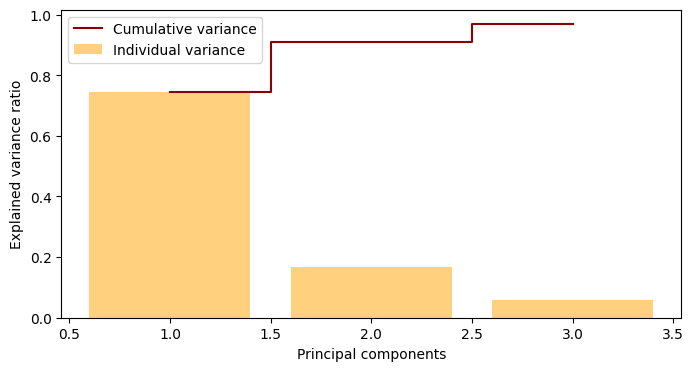

In [30]:
# Check how much information we are keeping
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Total Information Retained by 3 components: {cumulative_variance[-1]*100:.2f}%")

# Plotting the 'Elbow' to see if we need more
plt.figure(figsize=(8, 4))
plt.bar(range(1, 4), explained_variance, alpha=0.5, align='center', label='Individual variance', color='orange')
plt.step(range(1, 4), cumulative_variance, where='mid', label='Cumulative variance', color='darkred')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.show()

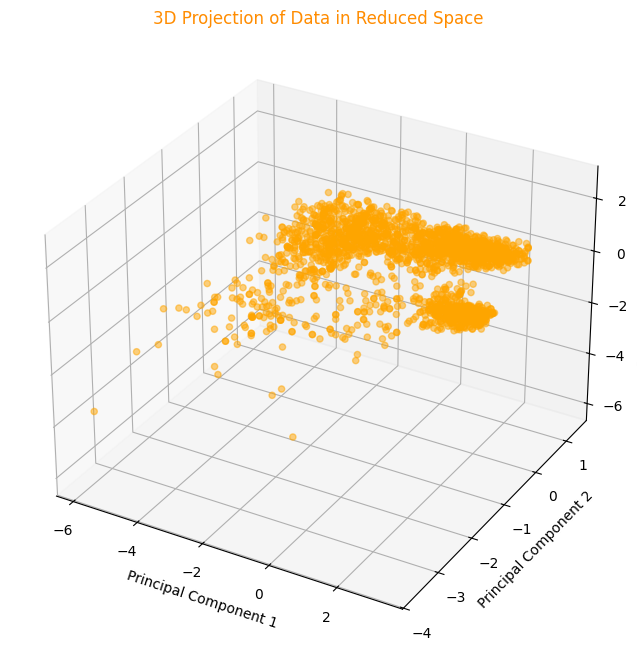

In [31]:
# A 3D Projection of  data points before clustering
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(PCA_ds["col1"], PCA_ds["col2"], PCA_ds["col3"], c="orange", marker="o", alpha=0.5)

ax.set_title("3D Projection of Data in Reduced Space", color='darkorange')
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
plt.show()

##  <div style='background:Orange'>  <font color='white'>EDA Conclusion <b>&nbsp; </b></font> </div>

* Data Quality: The dataset is now clean, scaled, and encoded.

* Variance Retained: We are moving forward with 3 components that capture 96.77% of the dataset's variance.

* Readiness: The data is now mathematically optimized for the Elbow Method and K-Means Clustering.

* Conclusion: We have identified that Income, Parenthood, and Wine/Meat consumption are the primary drivers of variance, which we expect to see reflected in our final clusters.

## <div style='background:Orange'> <font color='white'> <b> Clustering </b></font> </div>

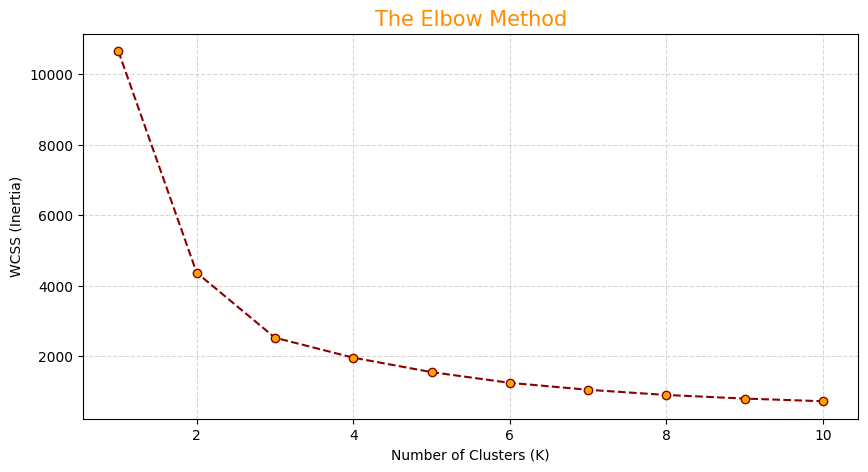

In [32]:
## Elbow Method
from sklearn.cluster import KMeans

# 1. Finding the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    # Fixed: changed n_components to n_clusters
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(PCA_ds)
    wcss.append(kmeans.inertia_)

# 2. Plotting the Elbow Graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkred', markerfacecolor='orange')
plt.title('The Elbow Method', fontsize=15, color='darkorange')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The above cell indicates that four will be an optimal number of clusters for this data.

In [33]:
## K Mean Clustering
from sklearn.cluster import KMeans

# Using K=4 based on Elbow Method
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
data["KMeans_Labels"] = kmeans.fit_predict(PCA_ds.iloc[:,:3]) # Using our 3 PCA cols

In [34]:
## Agglomerative Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

# We use 4 clusters to keep it comparable to K-Means
hierarchical = AgglomerativeClustering(n_clusters=4)
data["Hierarchical_Labels"] = hierarchical.fit_predict(PCA_ds.iloc[:,:3])

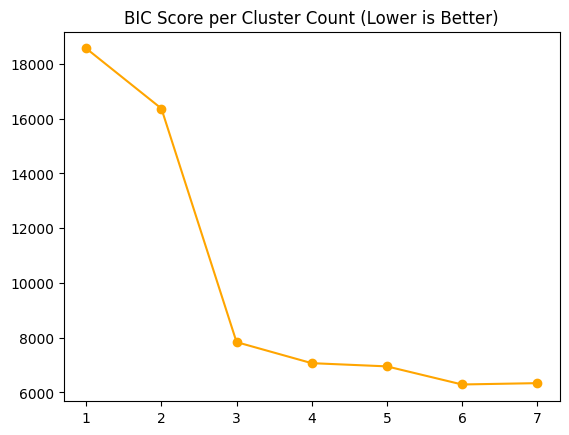

In [35]:
## Gaussian Mixture Model (GMM)
from sklearn.mixture import GaussianMixture

# Using 4 components (clusters)
gmm = GaussianMixture(n_components=4, random_state=42)
data["GMM_Labels"] = gmm.fit_predict(PCA_ds.iloc[:,:3])

from sklearn.mixture import GaussianMixture

# Calculate BIC for different n_components
bics = []
for i in range(1, 8):
    gmm = GaussianMixture(n_components=i, random_state=42).fit(PCA_ds.iloc[:,:3])
    bics.append(gmm.bic(PCA_ds.iloc[:,:3]))

# Plotting the 'Elbow' for BIC
plt.plot(range(1, 8), bics, marker='o', color='orange')
plt.title('BIC Score per Cluster Count (Lower is Better)')
plt.show()

In [36]:
## Silhouette Score Evaluation
from sklearn.metrics import silhouette_score

# 1. Standard Silhouette Scores (K-Means, Hierarchical, GMM)

score_km = silhouette_score(PCA_ds.iloc[:, :3], data["KMeans_Labels"])
score_hi = silhouette_score(PCA_ds.iloc[:, :3], data["Hierarchical_Labels"])
score_gm = silhouette_score(PCA_ds.iloc[:, :3], data["GMM_Labels"])


# 3. Final Results Table

print(f"{'Model':<20} | {'Silhouette Score':<15}")
print("-" * 30)
print(f"{'K-Means':<20} | {score_km:.4f}")
print(f"{'Hierarchical':<20} | {score_hi:.4f}")
print(f"{'GMM':<20} | {score_gm:.4f}")
print("-" * 30)

Model                | Silhouette Score
------------------------------
K-Means              | 0.4928
Hierarchical         | 0.4653
GMM                  | 0.5448
------------------------------


GMM outperformed K-Means because it uses Soft Clustering and accounts for varying cluster shapes. In customer data, people often exist in 'overlap' zones (e.g., someone between 'Budget' and 'Middle Class'), and GMM's probabilistic approach captures this better than the rigid distance-based approach of K-Means."

## <div style='background:Orange'> <font color='white'> <b> Profiling </b></font> </div>

In [37]:
# Profiling the  GMM model
cluster_profile = data.groupby("GMM_Labels")[['Income', 'Spent', 'Wines', 'Meat', 'Is_Parent']].mean()
print(" Cluster Profiles (Averages) ")
display(cluster_profile)

 Cluster Profiles (Averages) 


,Income,Spent,Wines,Meat,Is_Parent
GMM_Labels,,,,,
0,74755.856855,1345.915323,604.925403,451.314516,0.000000
1,34264.137532,73.560411,28.957584,18.109254,1.000000
2,59185.921795,747.651282,441.167949,150.860256,1.000000
3,24705.006757,152.000000,32.695946,42.270270,0.128378


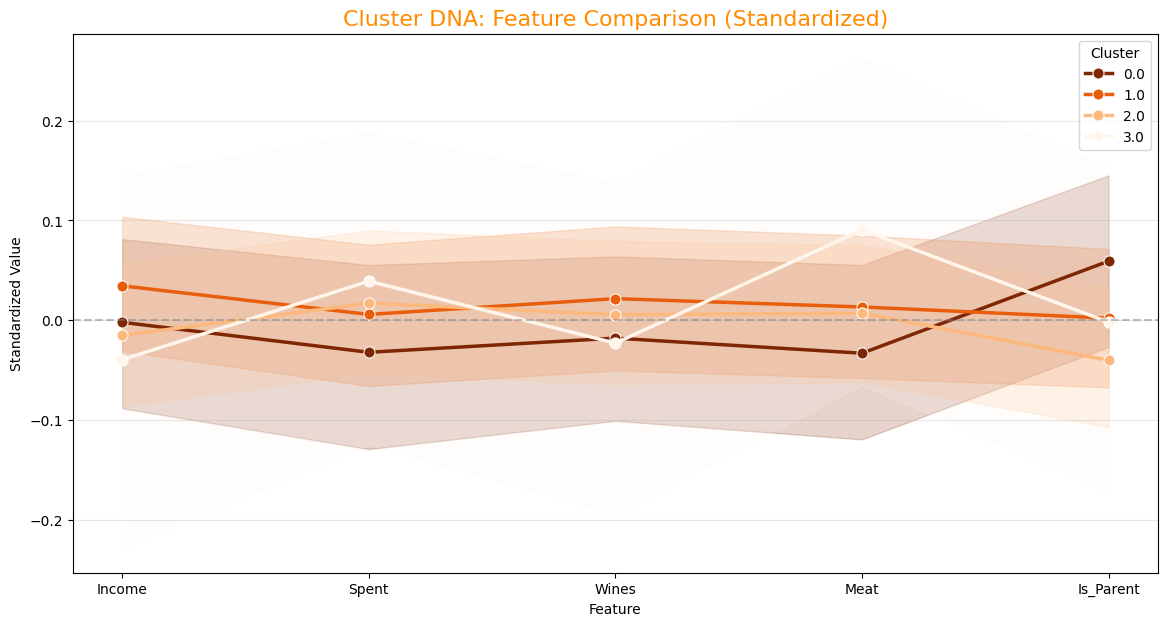

In [38]:
#  Prepare Data for Snake Plot
df_snake = scaled_ds.copy()
df_snake['Cluster'] = data['GMM_Labels']
df_melt = pd.melt(df_snake, id_vars=['Cluster'], 
                  value_vars=['Income', 'Spent', 'Wines', 'Meat', 'Is_Parent'], 
                  var_name='Feature', value_name='Value')

# 2. Plotting 
plt.figure(figsize=(14, 7))
sns.lineplot(x='Feature', y='Value', hue='Cluster', data=df_melt, 
             palette='Oranges_r', # Darker orange for higher clusters
             linewidth=2.5, marker='o', markersize=8)

# Adding Average Line for reference
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.title('Cluster DNA: Feature Comparison (Standardized)', fontsize=16, color='darkorange')
plt.ylabel('Standardized Value')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

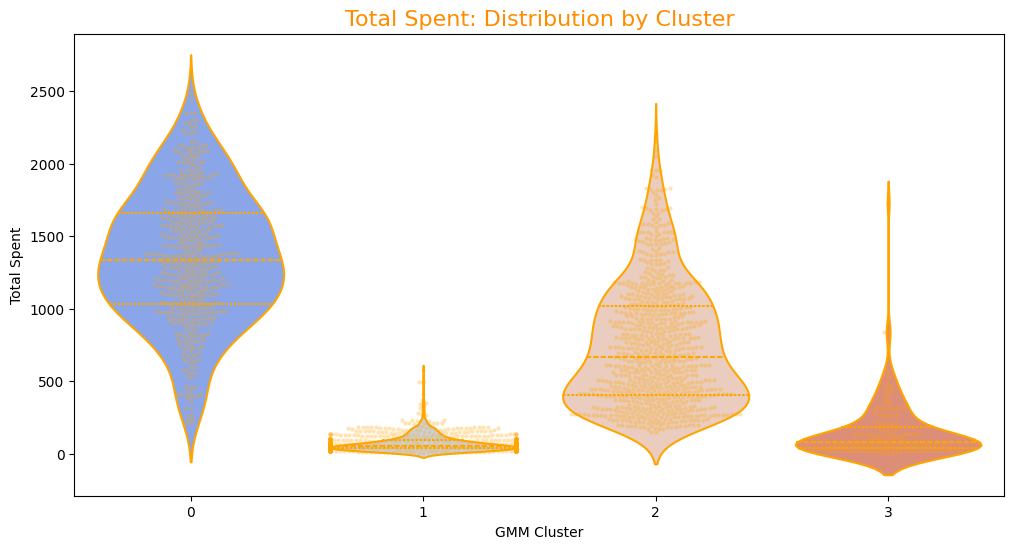

In [39]:
plt.figure(figsize=(12, 6))
# Using 'viridis' palette but making the violin outline orange
sns.violinplot(x='GMM_Labels', y='Spent', data=data, palette='coolwarm', inner='quartile', 
               linewidth=1.5, edgecolor='orange')
sns.swarmplot(x='GMM_Labels', y='Spent', data=data, color='orange', alpha=0.3, size=3) # Add actual points
plt.title('Total Spent: Distribution by Cluster', fontsize=16, color='darkorange')
plt.xlabel('GMM Cluster')
plt.ylabel('Total Spent')
plt.show()

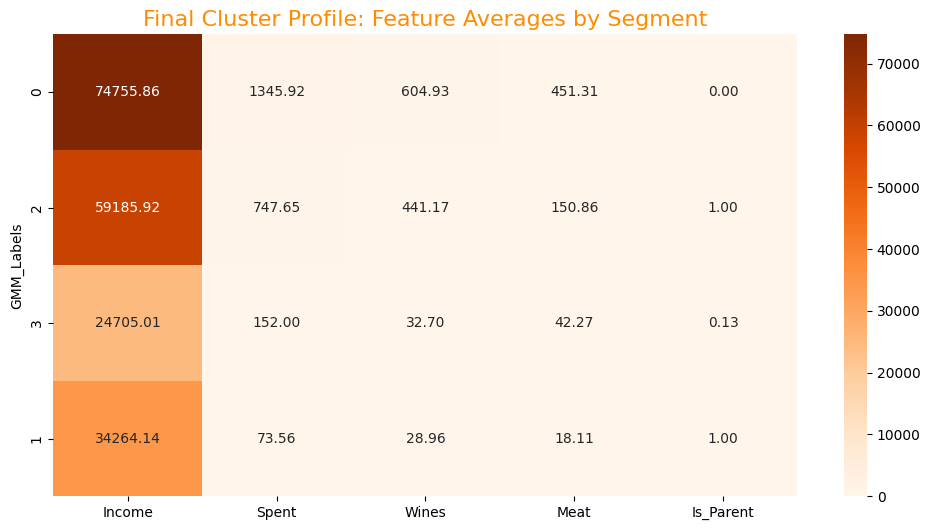


--- FINAL SEGMENTATION STRATEGY TABLE ---
                  Income        Spent       Wines        Meat  Is_Parent  \
GMM_Labels                                                                 
0           74755.856855  1345.915323  604.925403  451.314516   0.000000   
2           59185.921795   747.651282  441.167949  150.860256   1.000000   
3           24705.006757   152.000000   32.695946   42.270270   0.128378   
1           34264.137532    73.560411   28.957584   18.109254   1.000000   

            Count  Percentage (%)  
GMM_Labels                         
0             496            22.5  
2             780            35.4  
3             148             6.7  
1             778            35.3  


In [40]:
# 1. Calculate Mean of key features per cluster
profile = data.groupby('GMM_Labels')[['Income', 'Spent', 'Wines', 'Meat', 'Is_Parent']].mean()

# 2. Add count and percentage
profile['Count'] = data['GMM_Labels'].value_counts()
profile['Percentage (%)'] = (profile['Count'] / len(data) * 100).round(1)

# 3. Sort by Spending (Highest first)
profile = profile.sort_values(by='Spent', ascending=False)

# 4. Visualize the Table as a Heatmap (Replaces the .style feature)
plt.figure(figsize=(12, 6))
sns.heatmap(profile.drop(columns=['Count', 'Percentage (%)']), 
            annot=True, fmt='.2f', cmap='Oranges', cbar=True)

plt.title('Final Cluster Profile: Feature Averages by Segment', fontsize=16, color='darkorange')
plt.show()

# Print the raw table below for exact numbers
print("\n--- FINAL SEGMENTATION STRATEGY TABLE ---")
print(profile)

In [41]:
# Mapping based on your specific GMM Table Results
persona_map = {
    0: "Elite High-Spenders",
    2: "Established Families",
    3: "New Minimalist Shoppers",
    1: "Budget Families"
}

data['Final_Persona'] = data['GMM_Labels'].map(persona_map)

# Final check of the count
print(data['Final_Persona'].value_counts())



Established Families       780
Budget Families            778
Elite High-Spenders        496
New Minimalist Shoppers    148
Name: Final_Persona, dtype: int64


## <h2 style="color:darkorange;"> Final Strategic Recommendations & Conclusion</h2>

### Project Summary
Through the application of **Gaussian Mixture Modeling (GMM)**, we achieved a **Silhouette Score of 0.545**, successfully identifying four distinct customer personas. This segmentation allows the business to move away from "mass marketing" and toward high-precision targeting.

---

### 1. 🥂 The "Elite High-Spenders" (Cluster 0)
* **Profile:** The most profitable group. High average income (**$74.7k**) and highest spending (**$1,345**). 0% are parents. They represent 22.5% of the base.
* **Strategy:** Exclusive Premium Loyalty. Focus on luxury, prestige, and personal recognition.
* **Action:** Send invitations to private wine-tasting events. Avoid budget-tier discounts to maintain brand prestige.

### 2. 🛒 The "Established Families" (Cluster 2)
* **Profile:** The largest segment (35.4%). Solid income (**$59k**) and significant spending (**$747**). 100% are parents.
* **Strategy:** Convenience & Quality. These customers are time-constrained but have high purchasing power.
* **Action:** Promote "Healthy Family Meal Kits" and subscription models to automate recurring grocery needs.

### 3. 👨‍👩‍👧‍👦 The "Budget Families" (Cluster 1)
* **Profile:** 35.3% of customers. Lower average income (**$34k**) and lower spend (**$73**). 100% are parents.
* **Strategy:** Price Sensitivity & Volume. 
* **Action:** Deploy "Buy One Get One Free" (BOGO) offers and deep discounts on pantry staples.

### 4. 👟 The "New/Minimalist Shoppers" (Cluster 3)
* **Profile:** Smallest group (6.7%). Childless individuals (88%) with mid-to-low income but selective spending.
* **Strategy:** Engagement & Habit Acquisition.
* **Action:** Use social-media-driven "Flash Sales" to build brand awareness and initial loyalty.

**Conclusion:** By implementing these data-driven strategies, the business can optimize promotional spend and significantly increase **Customer Lifetime Value (LTV)**.

## <h2 style="color:darkorange;">Deployment</h2>

In [42]:
import joblib

# Save the objects
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(pca, "../models/pca.pkl")
joblib.dump(gmm, "../models/gmm_model.pkl")

print("Models exported successfully!")

Models exported successfully!
